# Tidy Data Project: Data Cleaning and Visualization

## Data Cleaning & Tidy Process

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("Data/fed_rd_year&gdp.csv")

# Look at the data
print("Original DataFrame:")
print(df.head())

Original DataFrame:
  department  1976_gdp1790000000000.0  1977_gdp2028000000000.0  \
0        DHS                      NaN                      NaN   
1        DOC             8.190000e+08             8.370000e+08   
2        DOD             3.569600e+10             3.796700e+10   
3        DOE             1.088200e+10             1.374100e+10   
4        DOT             1.142000e+09             1.095000e+09   

   1978_gdp2278000000000.0  1979_gdp2570000000000.0  1980_gdp2797000000000.0  \
0                      NaN                      NaN                      NaN   
1             8.710000e+08             9.520000e+08             9.450000e+08   
2             3.702200e+10             3.717400e+10             3.700500e+10   
3             1.566300e+10             1.561200e+10             1.522600e+10   
4             1.156000e+09             1.004000e+09             1.048000e+09   

   1981_gdp3138000000000.0  1982_gdp3314000000000.0  1983_gdp3541000000000.0  \
0                     

First, I loaded the federal research and development dataset and printed the first few rows so I can see what the current organization looks like. Currently, the data is in a wide format because each department appears in one row, while each year is stored as a separate column. The column names are not simple names, but a combination of both the year and the GDP value into a single column name.

This matters because the tidy data principles emphasize that each variable should be stored in its own column and each observation should be stored in its own row. In the current version of the dataset, the year and GDP are combined inside the column names, so the data is not tidy. An untidy dataset like this is much harder to analyze, summarize, and visualize.

In [22]:
#Show Summary Statistics
print("Summary Statistics:")
print(df.describe())

Summary Statistics:
       1976_gdp1790000000000.0  1977_gdp2028000000000.0  \
count             1.300000e+01             1.300000e+01   
mean              6.632846e+09             7.062077e+09   
std               9.753668e+09             1.045679e+10   
min               4.040000e+08             3.740000e+08   
25%               1.142000e+09             1.082000e+09   
50%               1.837000e+09             1.796000e+09   
75%               9.226000e+09             9.507000e+09   
max               3.569600e+10             3.796700e+10   

       1978_gdp2278000000000.0  1979_gdp2570000000000.0  \
count             1.300000e+01             1.300000e+01   
mean              7.297231e+09             7.430846e+09   
std               1.034816e+10             1.035569e+10   
min               3.560000e+08             3.530000e+08   
25%               1.156000e+09             1.102000e+09   
50%               1.962000e+09             2.321000e+09   
75%               1.053300e+10     

Next, I used describe() to create summary statistics for the numeric columns in the dataset. This helped me see the scale, spread, and range of the research and development spending values across years. This gave me a quick overview of the numbers in the dataset before reshaping it.

In [23]:
# Check for missing values
print("\nMissing values by column:")
print(df.isnull().sum())


Missing values by column:
department                  0
1976_gdp1790000000000.0     1
1977_gdp2028000000000.0     1
1978_gdp2278000000000.0     1
1979_gdp2570000000000.0     1
1980_gdp2797000000000.0     1
1981_gdp3138000000000.0     1
1982_gdp3314000000000.0     1
1983_gdp3541000000000.0     1
1984_gdp3953000000000.0     1
1985_gdp4270000000000.0     1
1986_gdp4536000000000.0     1
1987_gdp4782000000000.0     1
1988_gdp5155000000000.0     1
1989_gdp5570000000000.0     1
1990_gdp5915000000000.0     1
1991_gdp6110000000000.0     1
1992_gdp6435000000000.0     1
1993_gdp6795000000000.0     1
1994_gdp7198000000000.0     1
1995_gdp7583000000000.0     1
1996_gdp7978000000000.0     1
1997_gdp8483000000000.0     1
1998_gdp8955000000000.0     1
1999_gdp9511000000000.0     1
2000_gdp10148000000000.0    1
2001_gdp10565000000000.0    1
2002_gdp10877000000000.0    0
2003_gdp11332000000000.0    0
2004_gdp12089000000000.0    0
2005_gdp12889000000000.0    0
2006_gdp13685000000000.0    0
2007_gdp14323

I then checked for missing values in each column using isnull().sum(). This helped me see whether any department-year combinations were missing data before I reshaped the dataset.

This is important because missing values can impact data analysis and visualization. In this dataset, the missing values are mostly in the earlier years, which suggests that some departments did not yet have recorded research and development spending for those years. Looking at the spreadsheet the DHS has missing values from 1976-2001 which is why it is important to tidy the data from wide to long format so it is more evident which department the missing data comes from.

In [24]:
# Melt the data from wide to long format
df_melted = pd.melt(
    df,
    id_vars=['department'],
    value_vars = [
    '1976_gdp1790000000000.0',
    '1977_gdp2028000000000.0',
    '1978_gdp2278000000000.0',
    '1979_gdp2570000000000.0',
    '1980_gdp2797000000000.0',
    '1981_gdp3138000000000.0',
    '1982_gdp3314000000000.0',
    '1983_gdp3541000000000.0',
    '1984_gdp3953000000000.0',
    '1985_gdp4270000000000.0',
    '1986_gdp4536000000000.0',
    '1987_gdp4782000000000.0',
    '1988_gdp5155000000000.0',
    '1989_gdp5570000000000.0',
    '1990_gdp5915000000000.0',
    '1991_gdp6110000000000.0',
    '1992_gdp6435000000000.0',
    '1993_gdp6795000000000.0',
    '1994_gdp7198000000000.0',
    '1995_gdp7583000000000.0',
    '1996_gdp7978000000000.0',
    '1997_gdp8483000000000.0',
    '1998_gdp8955000000000.0',
    '1999_gdp9511000000000.0',
    '2000_gdp10148000000000.0',
    '2001_gdp10565000000000.0',
    '2002_gdp10877000000000.0',
    '2003_gdp11332000000000.0',
    '2004_gdp12089000000000.0',
    '2005_gdp12889000000000.0',
    '2006_gdp13685000000000.0',
    '2007_gdp14323000000000.0',
    '2008_gdp14752000000000.0',
    '2009_gdp14415000000000.0',
    '2010_gdp14799000000000.0',
    '2011_gdp15379000000000.0',
    '2012_gdp16027000000000.0',
    '2013_gdp16516000000000.0',
    '2014_gdp17244000000000.0',
    '2015_gdp17983000000000.0',
    '2016_gdp18470000000000.0',
    '2017_gdp19177000000000.0'],
    var_name='Year_GDP',
    value_name='R_D_Spending'
)

print("\nMelted DataFrame:")
print(df_melted)



Melted DataFrame:
    department                  Year_GDP  R_D_Spending
0          DHS   1976_gdp1790000000000.0           NaN
1          DOC   1976_gdp1790000000000.0  8.190000e+08
2          DOD   1976_gdp1790000000000.0  3.569600e+10
3          DOE   1976_gdp1790000000000.0  1.088200e+10
4          DOT   1976_gdp1790000000000.0  1.142000e+09
..         ...                       ...           ...
583        NIH  2017_gdp19177000000000.0  3.305200e+10
584        NSF  2017_gdp19177000000000.0  6.040000e+09
585      Other  2017_gdp19177000000000.0  1.553000e+09
586       USDA  2017_gdp19177000000000.0  2.625000e+09
587         VA  2017_gdp19177000000000.0  1.367000e+09

[588 rows x 3 columns]


I used pd.melt() to reshape the dataset from wide format to long format. I kept department as the identifier column using id_vars, and I listed the year/GDP columns as value_vars because those were the columns I wanted to unpivot into rows.

This step follows the Pandas Cheat Sheet where pd.melt(df) is a way to gather columns into rows. It also follows the tidy data principle that messy datasets often need to be melted when column headers contain values instead of variable names. The tidy data principles explain that a common form of messy data occurs when column headers are values and not variable names. So, the solution is to melt the data so those values become part of the rows instead.

After melting, each row represents one department paired with one combined year/GDP label and one research and development spending value. This tidies the dataset because observations are now organized row by row rather than spread across multiple columns.

In [25]:
# Split the combined Year_GDP column into two new columns
df_melted[['Year', 'GDP']] = df_melted['Year_GDP'].str.split('_gdp', expand=True)

print("\nDataFrame after splitting Year_GDP:")
print(df_melted.head())


DataFrame after splitting Year_GDP:
  department                 Year_GDP  R_D_Spending  Year              GDP
0        DHS  1976_gdp1790000000000.0           NaN  1976  1790000000000.0
1        DOC  1976_gdp1790000000000.0  8.190000e+08  1976  1790000000000.0
2        DOD  1976_gdp1790000000000.0  3.569600e+10  1976  1790000000000.0
3        DOE  1976_gdp1790000000000.0  1.088200e+10  1976  1790000000000.0
4        DOT  1976_gdp1790000000000.0  1.142000e+09  1976  1790000000000.0


After melting the dataset, the new Year_GDP column still combined multiple variables in one column. Specifically, each value combined both the year and the GDP into a single string. According to tidy data principles, this is still not fully tidy because each variable should have its own column.

To fix this, I used str.split() to split the values in Year_GDP at "_gdp" and expand the results into two new columns the Year and the GDP. The pandas website for Series.str.split() explains that expand=True returns the split pieces in separate columns, which is what the data needed. The tidy data principles also explain that most messy datasets can be cleaned with melting, casting, and in this case, string splitting.

In [29]:
# Clean the GDP column by removing .0
df_melted['GDP'] = df_melted['GDP'].str.replace('.0', '')

print("\nDataFrame after cleaning GDP:")
print(df_melted.head())


DataFrame after cleaning GDP:
  department                 Year_GDP  R_D_Spending  Year            GDP
0        DHS  1976_gdp1790000000000.0           NaN  1976  1790000000000
1        DOC  1976_gdp1790000000000.0  8.190000e+08  1976  1790000000000
2        DOD  1976_gdp1790000000000.0  3.569600e+10  1976  1790000000000
3        DOE  1976_gdp1790000000000.0  1.088200e+10  1976  1790000000000
4        DOT  1976_gdp1790000000000.0  1.142000e+09  1976  1790000000000


After splitting the Year_GDP column, the new GDP column still contained extra text, .0 at the end of each value. I used str.replace() to remove this unwanted information and make the column cleaner and easier to read. Cleaning the GDP column makes the final result more readable and more consistent with tidy data principles because the values are now stored in a clearer and more usable form.

In [45]:
# Remove the old combined column
df_tidy = df_melted.drop(columns=['Year_GDP'])

# Show the final cleaned dataframe
print("\nDataFrame after removing combined column:")
print(df_tidy)


DataFrame after removing combined column:
    department  R_D_Spending  Year             GDP
0          DHS           NaN  1976   1790000000000
1          DOC  8.190000e+08  1976   1790000000000
2          DOD  3.569600e+10  1976   1790000000000
3          DOE  1.088200e+10  1976   1790000000000
4          DOT  1.142000e+09  1976   1790000000000
..         ...           ...   ...             ...
583        NIH  3.305200e+10  2017  19177000000000
584        NSF  6.040000e+09  2017  19177000000000
585      Other  1.553000e+09  2017  19177000000000
586       USDA  2.625000e+09  2017  19177000000000
587         VA  1.367000e+09  2017  19177000000000

[588 rows x 4 columns]


Once I had created separate Year and GDP columns, the original Year_GDP column was no longer needed. I removed it because it still contained two variables combined in one column, which would go against the tidy data principle that each variable should be stored separately.

The Pandas Cheat Sheet includes df.drop(columns=[ ]) as a way to remove unnecessary columns from a dataframe. Removing the old combined column makes the data cleaner and ensures that the dataset now has one column for each variable: department, spending, year, and GDP.

In [47]:
# Rename the spending column to be more descriptive
df_tidy = df_tidy.rename(columns={
    'R_D_Spending': 'Research_and_Development_Spending'
})

# Show the final cleaned dataframe
print("\nDataFrame renaming the research and development spending column:")
print(df_tidy)


DataFrame renaming the research and development spending column:
    department  Research_and_Development_Spending  Year             GDP
0          DHS                                NaN  1976   1790000000000
1          DOC                       8.190000e+08  1976   1790000000000
2          DOD                       3.569600e+10  1976   1790000000000
3          DOE                       1.088200e+10  1976   1790000000000
4          DOT                       1.142000e+09  1976   1790000000000
..         ...                                ...   ...             ...
583        NIH                       3.305200e+10  2017  19177000000000
584        NSF                       6.040000e+09  2017  19177000000000
585      Other                       1.553000e+09  2017  19177000000000
586       USDA                       2.625000e+09  2017  19177000000000
587         VA                       1.367000e+09  2017  19177000000000

[588 rows x 4 columns]


I renamed R_D_Spending to Research_and_Development_Spending to make the column name easier to understand. Clear column names are helpful because they make the dataframe more readable for both the person doing the analysis and anyone else reading the notebook.

The Pandas Cheat Sheet lists df.rename(columns={...}) as the way to rename dataframe columns. This step improves clarity by creating a more meaningful or standardized label.

In [51]:
# Sort by Year in ascending order
df_tidy = df_tidy.sort_values(by='Year', ascending=True)

print("\nDataFrame Sorted by Year (Ascending):")
print(df_tidy.head(10))


DataFrame Sorted by Year (Ascending):
   department  Research_and_Development_Spending  Year            GDP
0         DHS                                NaN  1976  1790000000000
10        NSF                       2.372000e+09  1976  1790000000000
12       USDA                       1.837000e+09  1976  1790000000000
11      Other                       1.191000e+09  1976  1790000000000
9         NIH                       8.025000e+09  1976  1790000000000
8        NASA                       1.251300e+10  1976  1790000000000
7    Interior                       1.152000e+09  1976  1790000000000
6         HHS                       9.226000e+09  1976  1790000000000
5         EPA                       9.680000e+08  1976  1790000000000
4         DOT                       1.142000e+09  1976  1790000000000


After cleaning and renaming the columns, I sorted the dataframe by Year in ascending order. This places the observations in chronological order, which makes the final dataset easier to read and easier to use for later analysis.

The Pandas Cheat Sheet shows that df.sort_values('mpg') sorts a dataframe from low to high, while ascending=False sorts from high to low. Since my data is organized around time, sorting by year in ascending order is the most useful way to organize the final tidy dataframe.

In [52]:
print("\nFinal Tidy DataFrame:")
print(df_tidy)


Final Tidy DataFrame:
    department  Research_and_Development_Spending  Year             GDP
0          DHS                                NaN  1976   1790000000000
10         NSF                       2.372000e+09  1976   1790000000000
12        USDA                       1.837000e+09  1976   1790000000000
11       Other                       1.191000e+09  1976   1790000000000
9          NIH                       8.025000e+09  1976   1790000000000
..         ...                                ...   ...             ...
574        DHS                       7.350000e+08  2017  19177000000000
586       USDA                       2.625000e+09  2017  19177000000000
579        EPA                       5.060000e+08  2017  19177000000000
581   Interior                       9.550000e+08  2017  19177000000000
587         VA                       1.367000e+09  2017  19177000000000

[588 rows x 4 columns]


The final dataframe is now much more consistent with tidy data principles. Each variable has its own column (department, Research_and_Development_Spending, Year, and GDP), and each row represents one department-year observation. This structure makes the data easier to analyze, summarize, and visualize because the variables are clearly separated and the observations are organized consistently.

The tidy data principles explains that tidy datasets are easier to manipulate, model, and visualize because they follow a standard structure. The Pandas Cheat Sheet also notes that tidy data works especially well with pandas because pandas preserves observations as variables are manipulated.

## Visualization/EDA

In [61]:
#Check data types
print(df_tidy.info())
print(df_tidy.head())

<class 'pandas.core.frame.DataFrame'>
Index: 588 entries, 0 to 587
Data columns (total 4 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   department                         588 non-null    object 
 1   Research_and_Development_Spending  562 non-null    float64
 2   Year                               588 non-null    object 
 3   GDP                                588 non-null    object 
dtypes: float64(1), object(3)
memory usage: 23.0+ KB
None
   department  Research_and_Development_Spending  Year            GDP
0         DHS                                NaN  1976  1790000000000
10        NSF                       2.372000e+09  1976  1790000000000
12       USDA                       1.837000e+09  1976  1790000000000
11      Other                       1.191000e+09  1976  1790000000000
9         NIH                       8.025000e+09  1976  1790000000000


I first checked the structure of the tidy dataset to make sure that each column now represents a single variable and each row represents a single department-year observation. This is important to do before the exploratory data analysis because the data needs to be organized clearly before it can be grouped, summarized, or visualized.

the tidy data principles say that the variables should be separated into their own columns so for this data: department, Research_and_Development_Spending, Year, and GDP. Compared to the original wide-format dataset, this organization is much easier to work with is better for analysis.

In [65]:
#Convert columns to numeric
df_tidy['Year'] = pd.to_numeric(df_tidy['Year'])
df_tidy['GDP'] = pd.to_numeric(df_tidy['GDP'])
df_tidy['Research_and_Development_Spending'] = pd.to_numeric(
    df_tidy['Research_and_Development_Spending']
)

print(df_tidy.dtypes)

department                            object
Research_and_Development_Spending    float64
Year                                   int64
GDP                                    int64
dtype: object


After splitting the combined Year_GDP column earlier, the new Year and GDP columns were stored as strings because they were created using string operations. However, Year, GDP, and Research_and_Development_Spending all represent numeric values. I converted these columns to numeric using pd.to_numeric() from the Data Wrangling with pandas Cheat Sheet so they can be used for calculations, grouping, and plotting. This is important because tidy data is also about making sure variables are organzied in the correct format for analysis.

In [67]:
#Summary statistics on spending
print(df_tidy['Research_and_Development_Spending'].describe())

count    5.620000e+02
mean     1.083262e+10
std      1.813250e+10
min      3.130000e+08
25%      9.605000e+08
50%      2.155000e+09
75%      1.235450e+10
max      9.432500e+10
Name: Research_and_Development_Spending, dtype: float64


I used describe() to summarize the Research_and_Development_Spending variable. I chose this because the summary statistics provide a quick overview of the center, spread, and range of the spending values before the visualizations.

These numbers suggest that the spending values vary across the dataset. The large difference between the minimum and maximum values and the high standard deviation show that some department-year observations have much larger spending amounts than others.

In [68]:
#Check for missing values again
print(df_tidy.isnull().sum())

department                            0
Research_and_Development_Spending    26
Year                                  0
GDP                                   0
dtype: int64


I also checked for missing values again in the tidy dataset. This is important because missing data can affect both summary statistics and visualizations. In the tidy dataset, the missing values still appear in earlier years for DHS. Tidying the data makes missing values easier to interpret. Instead of seeing missing values scattered across many columns, I can see the specific department-year observations that do not have recorded spending values.

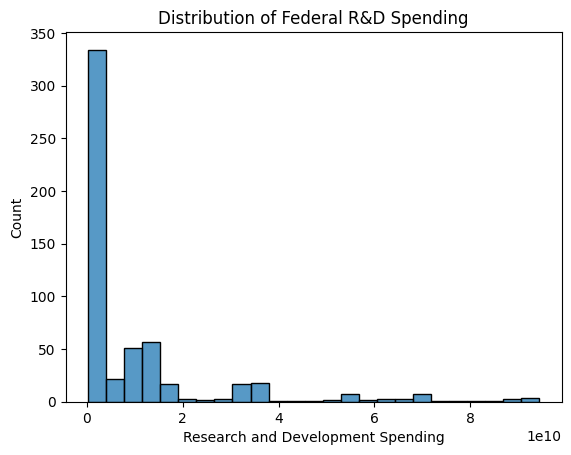

In [85]:
#Histogram of the distribution of spending
sns.histplot(df_tidy['Research_and_Development_Spending'], bins=25)
plt.title('Distribution of Federal R&D Spending')
plt.xlabel('Research and Development Spending')
plt.ylabel('Count')
plt.show()

I chose a histogram because it shows the distribution of a single numeric variable. I wanted to understand how research and development spending is spread across all department-year observations. Tidying the data makes this visualization easier to understand. In the original dataset, spending values were spread across many different columns, which made it difficult to examine the full distribution of spending at once. After tidying, all spending values are stored in a single column, so I can analyze the variable as a whole.

The histogram shows that most counts are concentrated at lower spending levels, while a smaller number of counts are much larger. This means the distribution is right-skewed. So, federal R&D spending is not evenly distributed across the dataset. A relatively small number of department-year counts are the large amounts of spending.

In [79]:
#groupby() to calculate the average research and development spending for each department
avg_spending_by_department = df_tidy.groupby('department')['Research_and_Development_Spending'].mean()

avg_spending_by_department = avg_spending_by_department.sort_values(
    ascending=False
)

print(avg_spending_by_department)

department
DOD         6.468519e+10
HHS         2.229676e+10
NIH         2.111757e+10
NASA        1.214026e+10
DOE         1.188338e+10
NSF         4.038810e+09
USDA        2.380810e+09
Other       1.494762e+09
DOC         1.231500e+09
DHS         9.948750e+08
DOT         9.177857e+08
Interior    9.005714e+08
EPA         7.504286e+08
VA          7.338810e+08
Name: Research_and_Development_Spending, dtype: float64


I used groupby() to calculate the average research and development spending for each department. I chose this summary because it helps compare departments overall rather than looking at one year at a time, this is much easier after tidying the data. Since department is now its own column and spending is stored in a single variable column, pandas can group the observations. In the original wide-format dataset, comparing departments across all years would have required working across many separate columns.

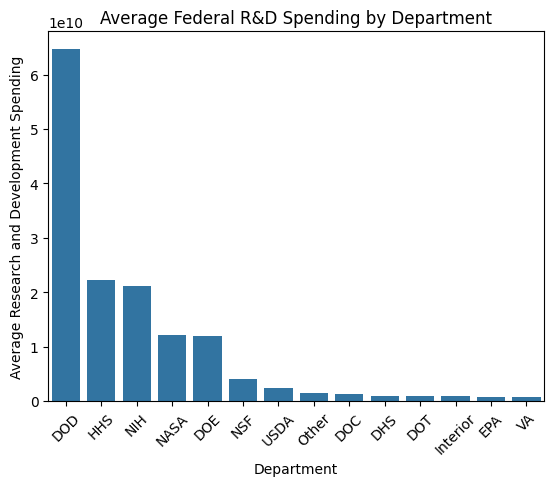

In [86]:
#Barchart of the avergae federal research and development spending by department
sns.barplot(
    x=avg_spending_by_department.index,
    y=avg_spending_by_department.values
)
plt.title('Average Federal R&D Spending by Department')
plt.xlabel('Department')
plt.ylabel('Average Research and Development Spending')
plt.xticks(rotation=45)
plt.show()

I chose a bar chart because it compares values across categories. The categories are departments, and I wanted to compare their average levels of research and development spending. This visualization shows that federal R&D spending is concentrated in a relatively small number of departments. DOD has the highest average spending by a large margin, followed by HHS and NIH. Departments such as EPA, VA, and Interior have much lower averages. This suggests that federal research and development funding is distributed unevenly, with a few major agencies receiving much larger shares of spending.

This graph was much easier to create because the data was tidied first. Once department and spending were separated into their own columns, I could group the data by department and compare categories directly in a bar chart.

In [81]:
#Group data by year and calculate sum spending for each year
spending_by_year = df_tidy.groupby('Year')['Research_and_Development_Spending'].sum()

print(spending_by_year.head())

Year
1976    8.622700e+10
1977    9.180700e+10
1978    9.486400e+10
1979    9.660100e+10
1980    9.630500e+10
Name: Research_and_Development_Spending, dtype: float64


Because the dataset includes time data, I also wanted to examine how total federal research and development spending changes over time. I grouped the data by Year and summed spending across departments to calculate the total amount spent in each year.

I chose this step because the tidied data makes analysis across time much easier. In the original dataset, year information was embedded inside the column names. After tidying, Year became its own variable, which allowed me to summarize and visualize spending over time much more clearly.

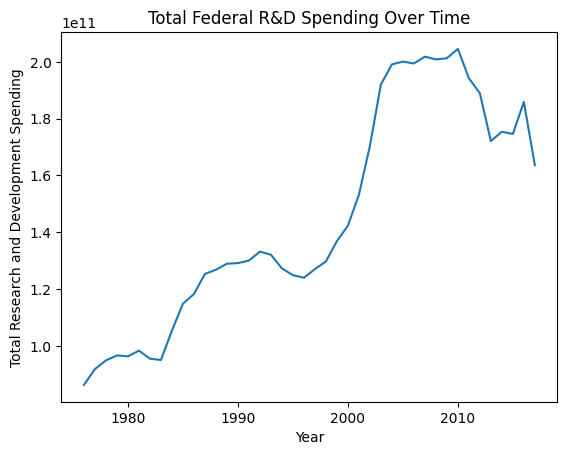

In [ ]:
#Lineplot of total research and development spending across time
sns.lineplot(
    x=spending_by_year.index,
    y=spending_by_year.values
)
plt.title('Total Federal R&D Spending Over Time')
plt.xlabel('Year')
plt.ylabel('Total Research and Development Spending')
plt.show()

I chose a line plot because it shows change over time. Since Year is now a separate column in the tidy dataset, I can track how total federal research and development spending changes from one year to the next.

The line plot shows an overall upward trend in total federal R&D spending across the full time period, even though the increase is not completely steady. Spending rises over time, but there is a dip around 1995, and then a noticeable decline in the early 2010s before the trend levels out and slightly recovers, and then dips again. This suggests that total spending grew over time, while still having periods of decline.

In the original wide-format dataset, year was combined in the column names, which made it much harder to create a clear time-series plot. After tidying, Year could be used directly as a variable, making the trend much easier to analyze and interpret.

In [84]:
pivot_department_mean = pd.pivot_table(
    df_tidy,
    values='Research_and_Development_Spending',
    index='department',
    aggfunc='mean'
)

pivot_department_mean = pivot_department_mean.sort_values(
    by='Research_and_Development_Spending',
    ascending=False
)

print(pivot_department_mean)

            Research_and_Development_Spending
department                                   
DOD                              6.468519e+10
HHS                              2.229676e+10
NIH                              2.111757e+10
NASA                             1.214026e+10
DOE                              1.188338e+10
NSF                              4.038810e+09
USDA                             2.380810e+09
Other                            1.494762e+09
DOC                              1.231500e+09
DHS                              9.948750e+08
DOT                              9.177857e+08
Interior                         9.005714e+08
EPA                              7.504286e+08
VA                               7.338810e+08


I also created a pivot table showing the average research and development spending by department. I chose a pivot table because it summarizes the tidy data in table form and makes it easy to compare departments numerically.

The pivot table shows the same pattern shown in the bar chart. DOD has the highest average spending, followed by HHS, NIH, NASA, and DOE. This means that the federal R&D spending is concentrated in a few major departments.

The visualizations and analysis of the cleaned dataset show that federal research and development spending is not evenly distributed across departments, and a few major agencies account for much higher average spending than the rest. The data also shows a general increase in total spending over time, although the trend includes some periods of decline.

By separating Year, GDP, department, and spending into their own columns, the dataset became much easier to summarize, compare, and visualize. The tidy data principles used made the structure of the dataset clearer and allowed the analysis and visualizations to show the data more clearly.